In [6]:
pip install geodatasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [geodatasets]
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install cartopy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 21.6 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [cartopy]m1/2 [cartopy]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd

df = pd.read_csv("/Users/pc/Desktop/2025/FireCube/FireCube-1/inputData/fireslist2012-2024.csv")


/var/folders/53/419gvyh13dzgnkd1zfn_g5jw0000gn/T/ipykernel_53840/2650406014.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  raw_sizes = pd.to_numeric(plot_df["BurnBndAc"], errors="ignore") if "BurnBndAc" in plot_df.columns else None


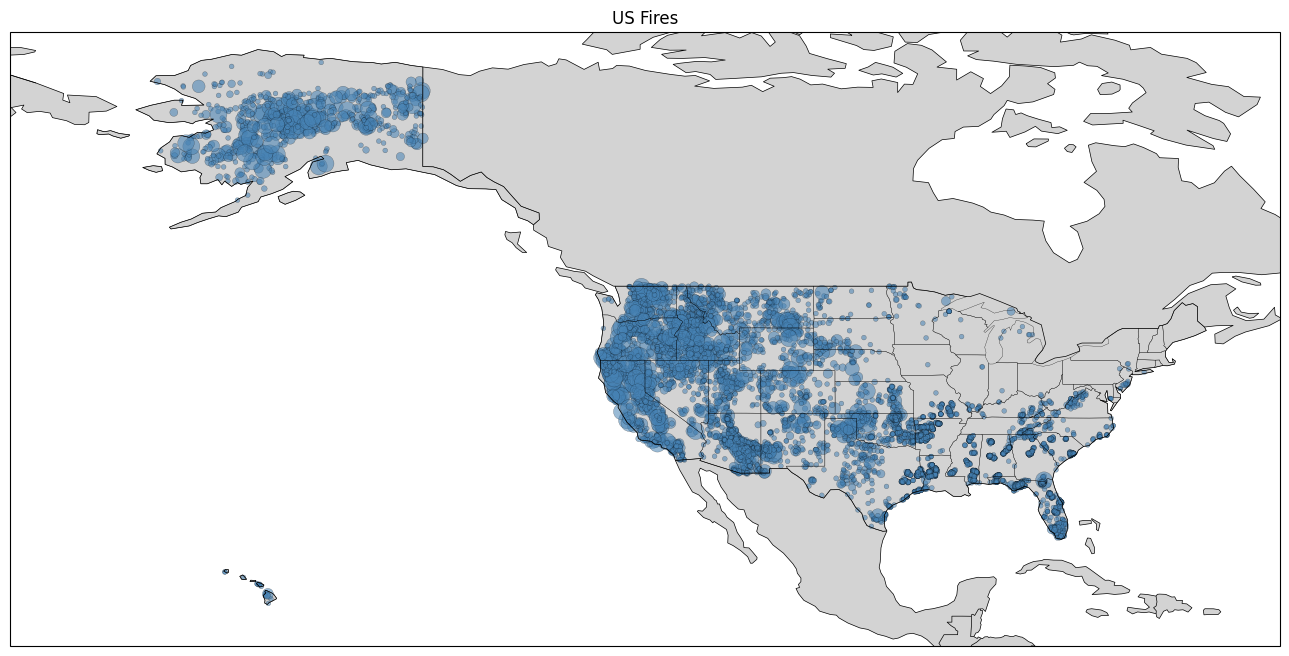

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

df["lon_mid"] = (pd.to_numeric(df["lon0"], errors="coerce") + pd.to_numeric(df["lon1"], errors="coerce")) / 2.0
df["lat_mid"] = (pd.to_numeric(df["lat0"], errors="coerce") + pd.to_numeric(df["lat1"], errors="coerce")) / 2.0

lon = df["lon_mid"].to_numpy(copy=True)
lon = np.where(lon > 180, lon - 360, lon)
df["lon_mid"] = lon

valid = df["lon_mid"].between(-180, 180) & df["lat_mid"].between(-90, 90)
plot_df = df.loc[valid].copy()

raw_sizes = pd.to_numeric(plot_df["BurnBndAc"], errors="ignore") if "BurnBndAc" in plot_df.columns else None
if raw_sizes is None or not np.issubdtype(raw_sizes.dtype, np.number):
    sizes = np.full(len(plot_df), 20.0)  # constant if area missing
else:
    s = raw_sizes.clip(lower=0)
    lo, hi = s.quantile(0.02), s.quantile(0.98)
    s = s.clip(lower=lo, upper=hi)
    sizes = (s / (hi if hi > 0 else 1.0)) * 150.0
    sizes = np.maximum(sizes, 12.0) # min visible size

fig = plt.figure(figsize=(13, 6.8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-180, -60, 15, 73], crs=ccrs.PlateCarree())

# Basemap
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
try:
    ax.add_feature(cfeature.STATES, linewidth=0.2)
except Exception:
    pass

ax.scatter(
    plot_df["lon_mid"], plot_df["lat_mid"],
    s=sizes, alpha=0.55, color="steelblue",
    linewidths=0.2, edgecolors="black",
    transform=ccrs.PlateCarree()
)

ax.set_title("US Fires")
plt.tight_layout()
plt.show()


Fires with valid size ≥ 4 km²: 7739


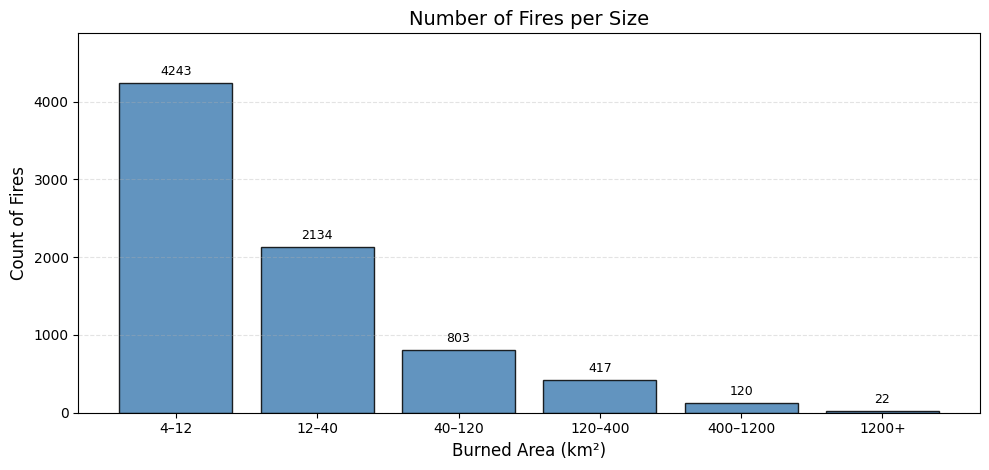

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET_YEAR = None
data = df.copy()
if TARGET_YEAR is not None and "Year" in data.columns:
    data = data[data["Year"] == TARGET_YEAR]

if "BurnBndAc" in data.columns:
    # acres to km²
    sizes_km2 = pd.to_numeric(data["BurnBndAc"], errors="coerce") * 0.00404686
else:
    # rough bbox area estimate (only used if BurnBndAc absent)
    lat_mid = (pd.to_numeric(data["lat0"], errors="coerce") + pd.to_numeric(data["lat1"], errors="coerce")) / 2
    dlat = (pd.to_numeric(data["lat1"], errors="coerce") - pd.to_numeric(data["lat0"], errors="coerce")).abs()
    dlon = (pd.to_numeric(data["lon1"], errors="coerce") - pd.to_numeric(data["lon0"], errors="coerce")).abs()
    km_per_deg_lat = 111.32
    km_per_deg_lon = 111.32 * np.cos(np.deg2rad(lat_mid))
    sizes_km2 = dlat * km_per_deg_lat * dlon * km_per_deg_lon

sizes_km2 = sizes_km2.replace([np.inf, -np.inf], np.nan).dropna()
sizes_km2 = sizes_km2[sizes_km2 >= 4]

print(f"Fires with valid size ≥ 4 km²: {len(sizes_km2)}")
if len(sizes_km2) == 0:
    raise SystemExit("No valid sizes ≥ 4 km² to plot.")

bins   = [4, 12, 40, 120, 400, 1200, np.inf]
labels = ["4–12", "12–40", "40–120", "120–400", "400–1200", "1200+"]

cats = pd.cut(sizes_km2, bins=bins, labels=labels, right=False, include_lowest=True)
counts = cats.value_counts().reindex(labels, fill_value=0)

plt.figure(figsize=(10, 4.8))
bars = plt.bar(counts.index, counts.values, color="steelblue",
               edgecolor="black", alpha=0.85)

ymax = counts.values.max()
plt.ylim(0, ymax * 1.15)

# value labels
for i, c in enumerate(counts.values):
    plt.text(i, c + ymax * 0.015, str(int(c)),
             ha='center', va='bottom', fontsize=9)

# styling
plt.title("Number of Fires per Size", fontsize=14)
plt.xlabel("Burned Area (km²)", fontsize=12)
plt.ylabel("Count of Fires", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()


Number of fires with valid duration: 7739
Median duration: 1.44 days


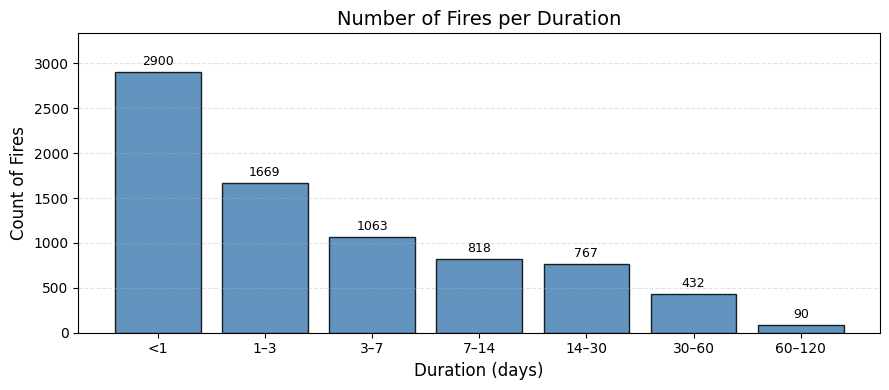

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tst_dt = pd.to_datetime(df["tst"], errors="coerce")
ted_dt = pd.to_datetime(df["ted"], errors="coerce")

# start time default to 1:30 AM
tst_dt = tst_dt.dt.floor("D") + pd.Timedelta(hours=1, minutes=30)

dur_days = (ted_dt - tst_dt).dt.total_seconds() / 86400.0
dur_days = dur_days.replace([np.inf, -np.inf], np.nan).dropna()
dur_days = dur_days[dur_days >= 0]

print(f"Number of fires with valid duration: {len(dur_days)}")
print(f"Median duration: {dur_days.median():.2f} days")

bins   = [0, 1, 3, 7, 14, 30, 60, 120]  # upper bound = 120
labels = ["<1", "1–3", "3–7", "7–14", "14–30", "30–60", "60–120"]

cats = pd.cut(dur_days, bins=bins, labels=labels, right=False, include_lowest=True)
counts = cats.value_counts().reindex(labels, fill_value=0)

plt.figure(figsize=(9, 4))
bars = plt.bar(counts.index, counts.values, color="steelblue", edgecolor="black", alpha=0.85)

plt.ylim(0, max(counts.values) * 1.15)

for i, c in enumerate(counts.values):
    plt.text(i, c + max(counts.values)*0.015, str(int(c)),
             ha='center', va='bottom', fontsize=9)

plt.title("Number of Fires per Duration", fontsize=14)
plt.xlabel("Duration (days)", fontsize=12)
plt.ylabel("Count of Fires", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()


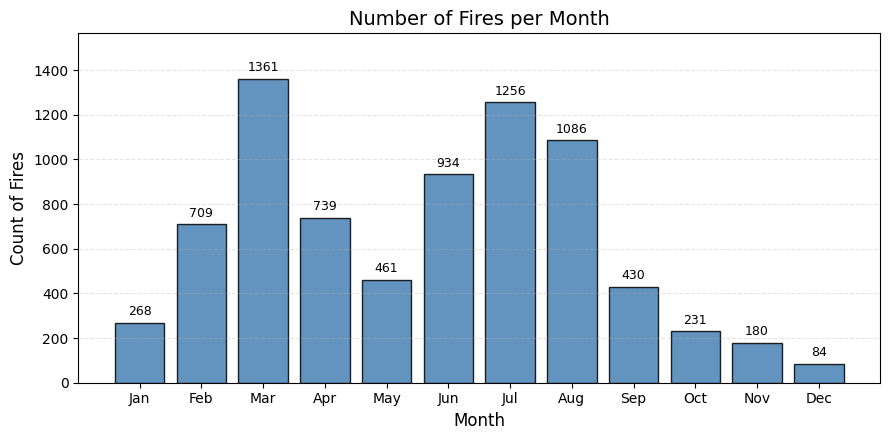

In [105]:
import pandas as pd
import matplotlib.pyplot as plt

tst_dt = pd.to_datetime(df["tst"], errors="coerce")

tst_dt = tst_dt.dropna()

months = tst_dt.dt.month
month_names = tst_dt.dt.month_name().str[:3]

counts = months.value_counts().sort_index()
month_labels = [pd.to_datetime(str(m), format='%m').strftime('%b') for m in counts.index]

plt.figure(figsize=(9, 4.5))
bars = plt.bar(month_labels, counts.values, color="steelblue", edgecolor="black", alpha=0.85)

ymax = counts.values.max()
plt.ylim(0, ymax * 1.15)

for i, c in enumerate(counts.values):
    plt.text(i, c + ymax * 0.015, str(int(c)), ha="center", va="bottom", fontsize=9)

plt.title("Number of Fires per Month", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Count of Fires", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()



Per-fire summaries (for plotting):
                                  fire_id  mean_vpd  mean_precip_mm  avg_spread_rate_km2_per_hr    spread_start_utc      spread_end_utc  spread_duration_hr
    data_table_CA4054112256820200927_ZOGG  2.938525        0.000387                    0.867479 2020-09-28 09:00:00 2020-10-03 08:00:00               119.0
data_table_NJ3932007511020140424_RAILROAD  0.752429        0.000533                    0.000000 2014-04-24 05:00:00 2014-04-25 04:00:00                23.0
   data_table_CA3720111927220200905_CREEK  1.074312        0.032902                    1.138225 2020-09-05 09:00:00 2020-11-06 08:00:00              1487.0
   data_table_AZ3500811387920200817_RIDGE  3.352508        0.199025                    0.099832 2020-08-17 08:00:00 2020-08-22 07:00:00               119.0


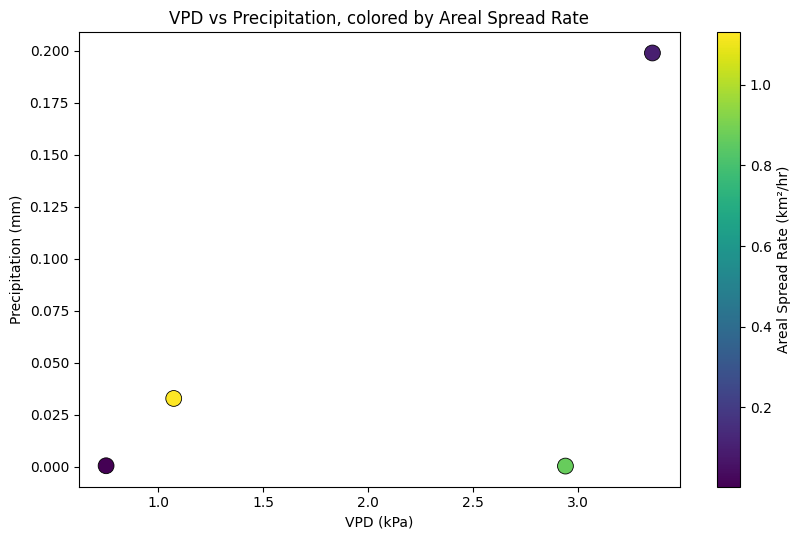

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FILES = [
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/CA4054112256820200927_ZOGG/data_table_CA4054112256820200927_ZOGG.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/NJ3932007511020140424_RAILROAD/data_table_NJ3932007511020140424_RAILROAD.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/CA3720111927220200905_CREEK/data_table_CA3720111927220200905_CREEK.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/AZ3500811387920200817_RIDGE/data_table_AZ3500811387920200817_RIDGE.csv",
]

def summarize_fire_option1_exact(path: str) -> dict | None:
    """
      • Computes long-window average areal spread rate (km²/hr) from fperim/fline.
      • Trims NaNs, then removes first and last 24 h of valid data.
      • Uses that same time range to compute mean VPD and mean precipitation.
      • Records the actual UTC time window used.
    """
    df = pd.read_csv(path, sep="\t")

    for col in ["UTC", "vpd", "tp"]:
        if col not in df.columns:
            print(f"[WARN] {Path(path).name}: missing required column {col!r}; skipping.")
            return None

    area_col = (
        "fperim_area_km2"
        if "fperim_area_km2" in df.columns
        else ("fline_area_km2" if "fline_area_km2" in df.columns else None)
    )
    if area_col is None:
        print(f"[WARN] {Path(path).name}: no area column found; skipping.")
        return None

    df["UTC"] = pd.to_datetime(df["UTC"], errors="coerce")
    df = df.dropna(subset=["UTC"]).sort_values("UTC")
    df[area_col] = pd.to_numeric(df[area_col], errors="coerce")
    df["vpd"] = pd.to_numeric(df["vpd"], errors="coerce")
    df["tp"] = pd.to_numeric(df["tp"], errors="coerce")

    area_hr = (
        df[["UTC", area_col]]
        .set_index("UTC")
        .resample("1h")
        .mean()
        .ffill(limit=12)
    )

    if area_hr.empty:
        print(f"[WARN] {Path(path).name}: empty hourly area; skipping.")
        return None

    area_valid = area_hr.dropna(subset=[area_col])
    if area_valid.empty:
        print(f"[WARN] {Path(path).name}: no valid area values; skipping.")
        return None

    if len(area_valid) > 48:
        area_trim = area_valid.iloc[24:-24]
    else:
        area_trim = area_valid

    if area_trim.empty:
        print(f"[WARN] {Path(path).name}: trimmed area window empty; skipping.")
        return None

    A0, A1 = area_trim[area_col].iloc[[0, -1]]
    t0, t1 = area_trim.index[[0, -1]]
    dt_h = (t1 - t0).total_seconds() / 3600.0
    avg_spread = (A1 - A0) / dt_h if dt_h and dt_h > 0 else np.nan

    met_hr = (
        df[["UTC", "vpd", "tp"]]
        .set_index("UTC")
        .resample("1h")
        .mean()
        .interpolate("time", limit=6)
    )

    met_trim = met_hr.loc[t0:t1]
    mean_vpd = met_trim["vpd"].mean() if "vpd" in met_trim else np.nan
    mean_precip_mm = met_trim["tp"].mean() if "tp" in met_trim else np.nan

    return {
        "fire_id": Path(path).stem,
        "mean_vpd": mean_vpd,
        "mean_precip_mm": mean_precip_mm,
        "avg_spread_rate_km2_per_hr": avg_spread,
        "spread_start_utc": t0,
        "spread_end_utc": t1,
        "spread_duration_hr": dt_h,
    }

rows = []
for p in FILES:
    try:
        rec = summarize_fire_option1_exact(p)
        if rec is not None:
            rows.append(rec)
    except Exception as e:
        print(f"[ERROR] {Path(p).name}: {e}")

fires = pd.DataFrame(rows)

# Drop fires without met or spread for plotting
plot_df = fires.dropna(subset=["mean_vpd", "mean_precip_mm", "avg_spread_rate_km2_per_hr"]).copy()

print("\nPer-fire summaries (for plotting):")
print(plot_df.to_string(index=False))

if plot_df.empty:
    raise SystemExit("Nothing to plot: missing met variables or spread after trimming.")

vmin, vmax = np.nanpercentile(plot_df["avg_spread_rate_km2_per_hr"], [1, 99])

plt.figure(figsize=(8.5, 5.5))
sc = plt.scatter(
    plot_df["mean_vpd"],
    plot_df["mean_precip_mm"],
    c=plot_df["avg_spread_rate_km2_per_hr"],
    vmin=vmin, vmax=vmax,
    s=130, edgecolors="black", linewidths=0.6
)
plt.xlabel("VPD (kPa)")
plt.ylabel("Precipitation (mm)")
plt.title("VPD vs Precipitation, colored by Areal Spread Rate")
cbar = plt.colorbar(sc)
cbar.set_label("Areal Spread Rate (km²/hr)")
plt.tight_layout()
plt.show()


                                     fire_id    spread_start_utc      spread_end_utc  duration_hr
0      data_table_CA4054112256820200927_ZOGG 2020-09-28 09:00:00 2020-10-03 08:00:00        119.0
1  data_table_NJ3932007511020140424_RAILROAD 2014-04-24 05:00:00 2014-04-25 04:00:00         23.0
2     data_table_CA3720111927220200905_CREEK 2020-09-05 09:00:00 2020-11-06 08:00:00       1487.0
3     data_table_AZ3500811387920200817_RIDGE 2020-08-17 08:00:00 2020-08-22 07:00:00        119.0


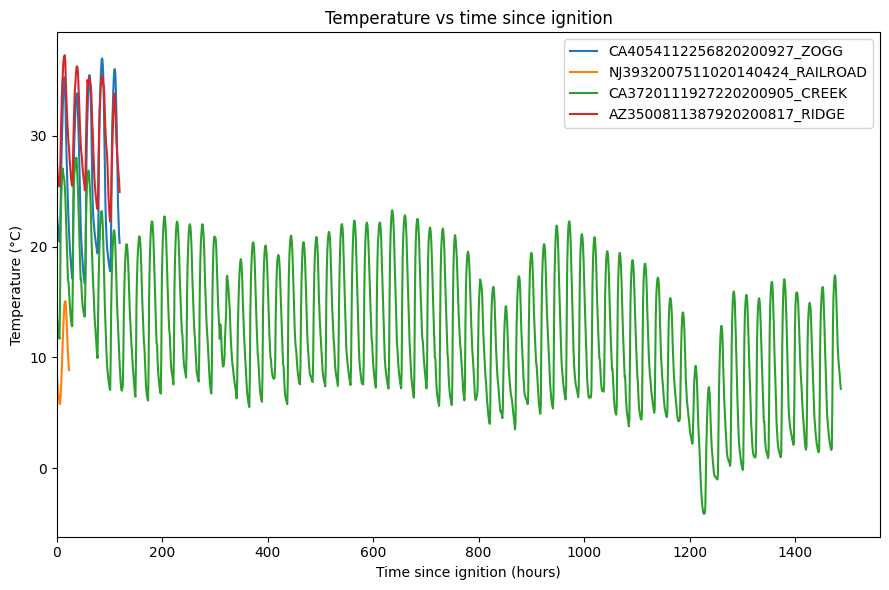

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FILES = [
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/CA4054112256820200927_ZOGG/data_table_CA4054112256820200927_ZOGG.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/NJ3932007511020140424_RAILROAD/data_table_NJ3932007511020140424_RAILROAD.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/CA3720111927220200905_CREEK/data_table_CA3720111927220200905_CREEK.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/AZ3500811387920200817_RIDGE/data_table_AZ3500811387920200817_RIDGE.csv",
]

def get_temperature_series(path):
    df = pd.read_csv(path, sep="\t")
    df["UTC"] = pd.to_datetime(df["UTC"], errors="coerce")
    df = df.dropna(subset=["UTC"]).sort_values("UTC")

    area_col = "fperim_area_km2" if "fperim_area_km2" in df.columns else (
               "fline_area_km2" if "fline_area_km2" in df.columns else None)
    if area_col is None:
        print(f"[WARN] {Path(path).stem}: no area column; skipping.")
        return None

    if "t2m" not in df.columns:
        print(f"[WARN] {Path(path).stem}: missing 't2m'; skipping.")
        return None

    # numeric conversions
    df[area_col] = pd.to_numeric(df[area_col], errors="coerce")
    df["t2m"] = pd.to_numeric(df["t2m"], errors="coerce")

    # hourly resamples
    area_hr = df.set_index("UTC")[[area_col]].resample("1h").mean().ffill(limit=12)
    temp_hr = df.set_index("UTC")[["t2m"]].resample("1h").mean().interpolate("time", limit=6)

    area_valid = area_hr.dropna(subset=[area_col])
    if area_valid.empty:
        print(f"[WARN] {Path(path).stem}: no valid area after NaN trim; skipping.")
        return None
    area_trim = area_valid.iloc[24:-24] if len(area_valid) > 48 else area_valid
    if area_trim.empty:
        print(f"[WARN] {Path(path).stem}: empty after padding trim; skipping.")
        return None

    t0, t1 = area_trim.index[[0, -1]]
    temp_trim = temp_hr.loc[t0:t1]

    time_since_ignition = (temp_trim.index - t0).total_seconds() / 3600.0

    return {
        "name": Path(path).stem,
        "t": time_since_ignition,
        "temp": temp_trim["t2m"].values,
        "t0": t0,
        "t1": t1,
        "hours": (t1 - t0).total_seconds() / 3600.0,
    }

series = []
rows = []
for p in FILES:
    rec = get_temperature_series(p)
    if rec:
        series.append(rec)
        rows.append({
            "fire_id": rec["name"],
            "spread_start_utc": rec["t0"],
            "spread_end_utc": rec["t1"],
            "duration_hr": rec["hours"],
        })

if rows:
    print(pd.DataFrame(rows))

# plot
plt.figure(figsize=(9, 6))
for rec in series:
    label = rec["name"].replace("data_table_", "").replace(".csv", "")
    plt.plot(rec["t"], rec["temp"], label=label)

plt.xlim(left=0)
plt.xlabel("Time since ignition (hours)")
plt.ylabel("Temperature (°C)")
plt.title("Temperature vs time since ignition")
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/53/419gvyh13dzgnkd1zfn_g5jw0000gn/T/ipykernel_53840/1800897774.py:82: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  keep_mask = ~labels.str.contains(exclude_regex, na=False)
/var/folders/53/419gvyh13dzgnkd1zfn_g5jw0000gn/T/ipykernel_53840/1800897774.py:82: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  keep_mask = ~labels.str.contains(exclude_regex, na=False)
/var/folders/53/419gvyh13dzgnkd1zfn_g5jw0000gn/T/ipykernel_53840/1800897774.py:82: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  keep_mask = ~labels.str.contains(exclude_regex, na=False)
/var/folders/53/419gvyh13dzgnkd1zfn_g5jw0000gn/T/ipykernel_53840/1800897774.py:82: UserWarning: This pattern is interpreted as a regular expression, and has match groups. T

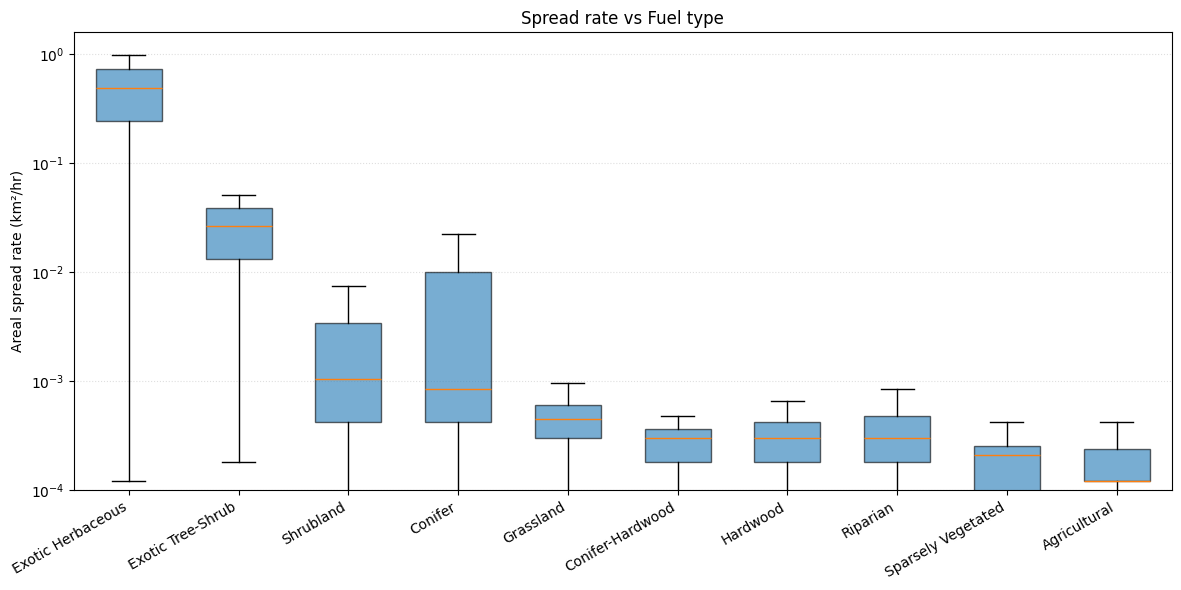

In [109]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from pathlib import Path
from collections import Counter

FILES = [
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/CA4054112256820200927_ZOGG/data_table_CA4054112256820200927_ZOGG.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/NJ3932007511020140424_RAILROAD/data_table_NJ3932007511020140424_RAILROAD.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/CA3720111927220200905_CREEK/data_table_CA3720111927220200905_CREEK.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/AZ3500811387920200817_RIDGE/data_table_AZ3500811387920200817_RIDGE.csv",
]
CUBES_ROOT = Path("/Users/pc/Desktop/2025/FireCube/FireCube-1/output/cubes")
EVT_CROSSWALK = Path("/Users/pc/Desktop/2025/FireCube/FireCube-1/inputData/LF2024_EVT.csv")
MIN_PER_CATEGORY = 1
USE_LOG_Y = True
TRIM_PAD_HOURS = 24

def _extract_fid_from_csv_path(p: Path) -> str:
    stem = p.stem
    if stem.startswith("data_table_"):
        rest = stem[len("data_table_"):]
        return rest.split("_")[0]
    return p.parent.name.split("_")[0]

def _label_column_in_crosswalk(df_cross):
    for c in ["EVT_PHYS", "EVT_PHYSCL", "EVT_NAME", "EVT_LF"]:
        if c in df_cross.columns:
            return c
    raise ValueError("Crosswalk must contain one of: EVT_PHYS, EVT_PHYSCL, EVT_NAME, EVT_LF")

def _find_evt_tif(fid: str) -> Path | None:
    landfire_dir = CUBES_ROOT / fid / "landfire"
    p = landfire_dir / "200evt.tif"
    if p.exists():
        return p
    cands = sorted(landfire_dir.glob("*evt*.tif")) or sorted(landfire_dir.glob("*.tif"))
    return cands[0] if cands else None

def _find_fperim_tif(fid: str) -> Path | None:
    p = CUBES_ROOT / fid / "fire_spread" / "fperim.tif"
    return p if p.exists() else None

def _valid_window_indices(series_hourly: pd.Series, pad_hours: int) -> tuple[int, int]:
    """
    Given a 1H-resampled cumulative area series (NaNs already dropped), return
    inclusive band-span indices [lo_idx, hi_idx] after trimming first/last pad_hours.
    If too short, return the tightest possible window.
    """
    n = len(series_hourly)
    if n == 0:
        return 0, -1
    lo = min(pad_hours, max(0, n - 1))
    hi = max(lo, n - 1 - pad_hours)
    return lo, hi

def build_allowed_evt_codes(xwalk: pd.DataFrame, label_col: str) -> set[int]:
    """
    Return a set of EVT VALUE codes considered burnable vegetation.
    Excludes developed/roads/water/snow/quarries & pads.
    """
    if "VALUE" not in xwalk.columns:
        raise ValueError("Crosswalk must include a 'VALUE' column (EVT code).")

    exclude_regex = re.compile(
        r"(?:^|\b)"
        r"(Developed(?:-.+)?"
        r"|Roads"
        r"|Open\s*Water"
        r"|Snow[-– ]?Ice"
        r"|Quarries"
        r"|Strip\s*Mines"
        r"|Gravel\s*Pits"
        r"|Well\s*(?:and|&)\s*Wind\s*Pads)"
        r"(?:\b|$)",
        flags=re.IGNORECASE,
    )

    labels = xwalk[label_col].astype(str).fillna("")
    keep_mask = ~labels.str.contains(exclude_regex, na=False)
    allowed = set(xwalk.loc[keep_mask, "VALUE"].astype(int).tolist())
    return allowed

def _per_evt_spread_for_one_fire(fid: str, trim_pad_hours: int, crosswalk: pd.DataFrame, label_col: str) -> pd.DataFrame | None:
    fperim_tif = _find_fperim_tif(fid)
    evt_tif = _find_evt_tif(fid)
    if fperim_tif is None or evt_tif is None:
        return None

    HOURS_PER_STEP = 12
    PADDING_HOURS_EACH_SIDE = 24
    PAD_BANDS = PADDING_HOURS_EACH_SIDE // HOURS_PER_STEP

    with rasterio.open(evt_tif) as ds_evt:
        EVT = ds_evt.read(1)
        if ds_evt.nodata is not None:
            EVT = np.where(EVT == ds_evt.nodata, 0, EVT)

    allowed_codes = build_allowed_evt_codes(crosswalk, label_col)

    csv_guess = next((p for p in FILES if _extract_fid_from_csv_path(Path(p)) == fid), None)
    if csv_guess is None:
        return None
    df = pd.read_csv(csv_guess, sep="\t")
    if "UTC" not in df.columns:
        return None
    df["UTC"] = pd.to_datetime(df["UTC"], errors="coerce")
    df = df.dropna(subset=["UTC"]).sort_values("UTC")
    area_col = "fperim_area_km2" if "fperim_area_km2" in df.columns else ("fline_area_km2" if "fline_area_km2" in df.columns else None)
    if area_col is None:
        return None
    df[area_col] = pd.to_numeric(df[area_col], errors="coerce")

    area_hr = (df.set_index("UTC")[[area_col]].resample("1h").mean().ffill(limit=12)).dropna()
    if area_hr.empty:
        return None
    lo_idx, hi_idx = _valid_window_indices(area_hr[area_col], trim_pad_hours)
    area_trim = area_hr.iloc[lo_idx:hi_idx+1]
    if area_trim.empty or len(area_trim) < 2:
        return None

    hours_in_window = (area_trim.index[-1] - area_trim.index[0]).total_seconds() / 3600.0
    if hours_in_window <= 0:
        return None

    with rasterio.open(fperim_tif) as ds_fp:
        pix_km2 = abs(ds_fp.transform.a * ds_fp.transform.e) / 1e6
        B = ds_fp.count
        if B <= 2 * PAD_BANDS + 1:
            return None

        start_band = 1 + PAD_BANDS
        end_band   = B - PAD_BANDS

        acc = Counter()
        prev = (ds_fp.read(start_band) > 0)
        used_steps = 0
        for b in range(start_band + 1, end_band + 1):
            cur = (ds_fp.read(b) > 0)
            new = cur & (~prev)
            if new.any():
                codes, counts = np.unique(EVT[new], return_counts=True)
                for c, v in zip(codes, counts):
                    c = int(c)
                    if c > 0 and c in allowed_codes:
                        acc[c] += v * pix_km2
            prev = cur
            used_steps += 1

    if not acc or used_steps == 0:
        return None

    total_hours = hours_in_window

    out = pd.DataFrame({"VALUE": list(acc.keys()), "area_km2": list(acc.values())})
    out["rate_km2_hr"] = out["area_km2"] / float(total_hours)
    out = out.merge(crosswalk[["VALUE", label_col]], on="VALUE", how="left")
    out.rename(columns={label_col: "EVT_PHYS"}, inplace=True)
    out["fire_id"] = fid
    return out[["fire_id", "VALUE", "EVT_PHYS", "rate_km2_hr"]]

xwalk = pd.read_csv(EVT_CROSSWALK)
label_col = _label_column_in_crosswalk(xwalk)

all_rows = []
for f in FILES:
    fid = _extract_fid_from_csv_path(Path(f))
    df_evt = _per_evt_spread_for_one_fire(fid, TRIM_PAD_HOURS, xwalk, label_col)
    if df_evt is not None and not df_evt.empty:
        all_rows.append(df_evt)

if not all_rows:
    raise SystemExit("No per-EVT data to plot. Check fperim/EVT rasters and CSV columns.")

df_all = pd.concat(all_rows, ignore_index=True)
df_all = df_all.dropna(subset=["EVT_PHYS", "rate_km2_hr"])

counts = df_all.groupby("EVT_PHYS")["fire_id"].nunique()
keep_evt = counts[counts >= MIN_PER_CATEGORY].index
df_plot = df_all[df_all["EVT_PHYS"].isin(keep_evt)].copy()
if df_plot.empty:
    df_plot = df_all.copy()

order = (
    df_plot.groupby("EVT_PHYS")["rate_km2_hr"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)
df_plot["EVT_PHYS"] = pd.Categorical(df_plot["EVT_PHYS"], categories=order, ordered=True)
df_plot = df_plot.sort_values("EVT_PHYS")

plt.figure(figsize=(12, 6))
groups = [g["rate_km2_hr"].values for _, g in df_plot.groupby("EVT_PHYS")]
positions = np.arange(1, len(groups) + 1)

bp = plt.boxplot(groups, positions=positions, widths=0.6, patch_artist=True, showfliers=False)
for b in bp["boxes"]:
    b.set(alpha=0.6)

labels = [evt for evt in df_plot["EVT_PHYS"].unique()]
plt.xticks(positions, labels, rotation=30, ha="right")

plt.ylabel("Areal spread rate (km²/hr)")
plt.title("Spread rate vs Fuel type")

if USE_LOG_Y:
    positive = df_plot["rate_km2_hr"][df_plot["rate_km2_hr"] > 0]
    if not positive.empty:
        plt.yscale("log")
        plt.ylim(bottom=max(1e-4, positive.min() * 0.5))
        plt.tick_params(axis="y", which="minor", length=0)

plt.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()


                                     fire_id      elev_start_utc        elev_end_utc  duration_hr
0      data_table_CA4054112256820200927_ZOGG 2020-09-27 09:00:00 2020-10-03 08:00:00        143.0
1  data_table_NJ3932007511020140424_RAILROAD 2014-04-23 05:00:00 2014-04-25 04:00:00         47.0
2     data_table_CA3720111927220200905_CREEK 2020-09-04 09:00:00 2020-11-06 08:00:00       1511.0
3     data_table_AZ3500811387920200817_RIDGE 2020-08-16 08:00:00 2020-08-22 07:00:00        143.0


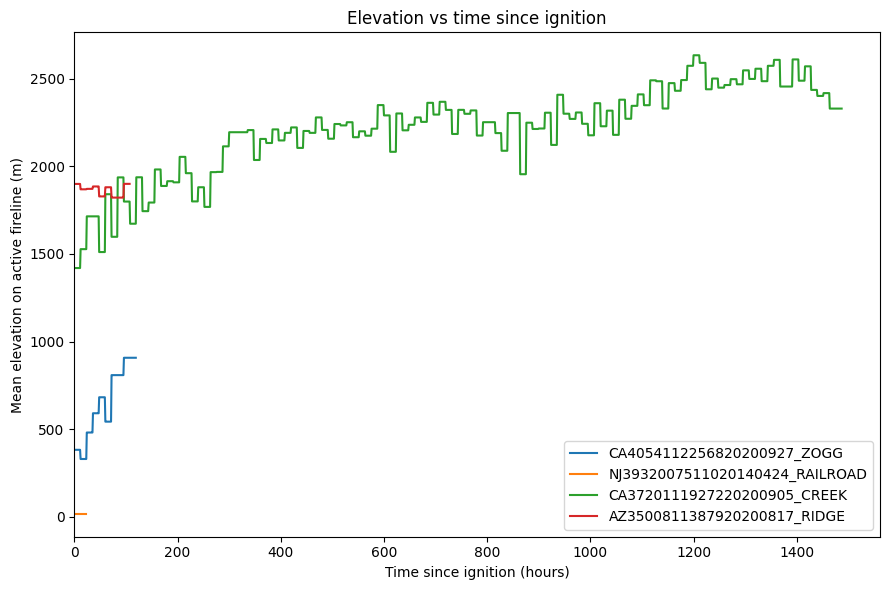

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FILES = [
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/CA4054112256820200927_ZOGG/data_table_CA4054112256820200927_ZOGG.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/NJ3932007511020140424_RAILROAD/data_table_NJ3932007511020140424_RAILROAD.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/CA3720111927220200905_CREEK/data_table_CA3720111927220200905_CREEK.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/AZ3500811387920200817_RIDGE/data_table_AZ3500811387920200817_RIDGE.csv",
]

def get_elevation_series(path):
    df = pd.read_csv(path, sep="\t")
    df["UTC"] = pd.to_datetime(df["UTC"], errors="coerce")
    df = df.dropna(subset=["UTC"]).sort_values("UTC")

    area_col = "fperim_area_km2" if "fperim_area_km2" in df.columns else (
               "fline_area_km2" if "fline_area_km2" in df.columns else None)
    if area_col is None:
        print(f"[WARN] {Path(path).stem}: no area column; skipping.")
        return None

    elev_col = None
    if "fline_mean_elev_m" in df.columns:
        elev_col = "fline_mean_elev_m"
    elif "elev_mean" in df.columns:
        elev_col = "elev_mean"
    else:
        print(f"[WARN] {Path(path).stem}: missing elevation column ('fline_mean_elev_m' or 'elev_mean'); skipping.")
        return None

    df[area_col] = pd.to_numeric(df[area_col], errors="coerce")
    df[elev_col] = pd.to_numeric(df[elev_col], errors="coerce")

    area_hr = df.set_index("UTC")[[area_col]].resample("1h").mean().ffill(limit=12)
    elev_hr = df.set_index("UTC")[[elev_col]].resample("1h").mean().interpolate("time", limit=6)

    area_valid = area_hr.dropna(subset=[area_col])
    if area_valid.empty:
        print(f"[WARN] {Path(path).stem}: no valid area after NaN trim; skipping.")
        return None

    if len(area_valid) > 24:
        area_trim = area_valid.iloc[:-24]
    else:
        area_trim = area_valid

    if area_trim.empty:
        print(f"[WARN] {Path(path).stem}: empty after trimming last 24h; skipping.")
        return None

    t0, t1 = area_trim.index[[0, -1]]

    elev_window = elev_hr.loc[t0:t1].interpolate("time", limit=6)
    elev_valid  = elev_window.dropna(subset=[elev_col])

    if elev_valid.empty:
        print(f"[WARN] {Path(path).stem}: no non-NaN elevation in window; skipping.")
        return None

    t0_elev = elev_valid.index[0]

    elev_trim = elev_valid.reindex(pd.date_range(t0_elev, t1, freq="1h")).interpolate("time")

    time_since_ignition = (elev_trim.index - t0_elev).total_seconds() / 3600.0


    return {
        "name": Path(path).stem,
        "t": time_since_ignition,
        "elev": elev_trim[elev_col].values,
        "t0": t0,
        "t1": t1,
        "hours": (t1 - t0).total_seconds() / 3600.0,
    }

series = []
rows = []
for p in FILES:
    rec = get_elevation_series(p)
    if rec:
        series.append(rec)
        rows.append({
            "fire_id": rec["name"],
            "elev_start_utc": rec["t0"],
            "elev_end_utc": rec["t1"],
            "duration_hr": rec["hours"],
        })

if rows:
    print(pd.DataFrame(rows))

# plot
plt.figure(figsize=(9, 6))
for rec in series:
    label = rec["name"].replace("data_table_", "").replace(".csv", "")
    plt.plot(rec["t"], rec["elev"], label=label)

plt.xlim(left=0)
plt.xlabel("Time since ignition (hours)")
plt.ylabel("Mean elevation on active fireline (m)")
plt.title("Elevation vs time since ignition")
plt.legend()
plt.tight_layout()
plt.show()
